<a href="https://colab.research.google.com/github/Arup3201/reint/blob/main/forecast_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REint: Forecast Analysis

In [1]:
import json
import requests
from datetime import datetime
from collections import defaultdict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def load_dataset(output_file: str = "dataset.json") -> None:
    wind_api = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom=2024-01-01&settlementDateTo=2024-01-31&fuelType=WIND"
    forecast_api = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom=2024-01-01&publishDateTimeTo=2024-01-31"

    # Fetch actual wind data
    res = requests.get(wind_api)
    res.raise_for_status()
    actual_wind_data = res.json()

    # Fetch forecasted wind data
    res = requests.get(forecast_api)
    res.raise_for_status()
    forecasted_wind_data = res.json()

    # Build a lookup map from startTime -> list of forecast entries
    forecast_map = defaultdict(list)
    for entry in forecasted_wind_data:
        forecast_map[entry["startTime"]].append(entry)

    dataset = []
    for actual in actual_wind_data:
        start_time = actual["startTime"]
        forecasts = forecast_map.get(start_time)

        if forecasts:
            # One row per forecast matched to this actual startTime
            for forecast in forecasts:
                dataset.append({
                    "targetTime":  start_time,
                    "publishTime": forecast["publishTime"],
                    "actual":      actual["generation"],
                    "forecast":    forecast["generation"],
                })
        else:
            dataset.append({
                "targetTime":  start_time,
                "publishTime": None,
                "actual":      actual["generation"],
                "forecast":    None,
            })

    # Sort by targetTime ascending
    dataset.sort(key=lambda x: datetime.fromisoformat(x["targetTime"]))

    # Persist to JSON file instead of a global variable
    with open(output_file, "w") as f:
        json.dump(dataset, f, indent=2)


In [3]:
load_dataset()

In [4]:
def read_dataset(input_file: str = "dataset.json") -> pd.DataFrame:
    df = pd.read_json(input_file)
    df["targetTime"] = pd.to_datetime(df["targetTime"])
    df["publishTime"] = pd.to_datetime(df["publishTime"])
    return df

In [5]:
dataset = read_dataset()

In [6]:
dataset.head()

,targetTime,publishTime,actual,forecast
0,2024-01-01 00:00:00+00:00,NaT,10402,NaN
1,2024-01-01 00:30:00+00:00,NaT,10845,NaN
2,2024-01-01 01:00:00+00:00,NaT,11218,NaN
3,2024-01-01 01:30:00+00:00,NaT,11223,NaN
4,2024-01-01 02:00:00+00:00,NaT,11234,NaN


In [7]:
df = dataset[dataset["forecast"].notna()]

In [8]:
df.head()

,targetTime,publishTime,actual,forecast
42,2024-01-01 21:00:00+00:00,2024-01-01 22:30:00+00:00,13953,11736.0
43,2024-01-01 21:00:00+00:00,2024-01-01 18:30:00+00:00,13953,11730.0
44,2024-01-01 21:00:00+00:00,2024-01-01 15:30:00+00:00,13953,10634.0
45,2024-01-01 21:00:00+00:00,2024-01-01 11:30:00+00:00,13953,10072.0
46,2024-01-01 21:00:00+00:00,2024-01-01 09:30:00+00:00,13953,10065.0


## Forecast Error

$error=actual-forecast$

In [9]:
errors = df["actual"] - df["forecast"]

In [10]:
avg_signed_error = errors.mean()
print(f"Average Signed Error: {avg_signed_error:.2f} MW")

Average Signed Error: -1418.44 MW


Mean Error: -1418.44 MW

**Model forecasts too high.**

In [11]:
median_error = errors.median()
print(f"Median Error: {median_error:.2f} MW")

Median Error: -1444.50 MW


**The typical model error is -1444.50 MW**

In [12]:
p99_abs_error = errors.abs().quantile(0.99)
print(f"P99 Absolute Error: {p99_abs_error:.2f} MW")

P99 Absolute Error: 6897.06 MW


**99% of the time the error is less than 6897.06 MW**

In [13]:
p95_abs_error = errors.abs().quantile(0.95)
print(f"P99 Absolute Error: {p95_abs_error:.2f} MW")

P99 Absolute Error: 4705.00 MW


In [14]:
p90_abs_error = errors.abs().quantile(0.90)
print(f"P99 Absolute Error: {p90_abs_error:.2f} MW")

P99 Absolute Error: 4174.00 MW


**90% of the time the error is less than 4174 MW**

Looking at the difference between 99%, 95% and 90%, there are few outliers present.

In [15]:
mae = errors.abs().mean()
print(f"MAE: {mae:.2f} MW")

MAE: 2146.45 MW


Mean Absolute Error: 2146.45 MW

**The models prediction is typically off by 2146.45 MW. Since UK wind generation ranges roughly from 0-20000 MW, this gives a sense that the model is not performing well.**

In [16]:
rmse = (errors ** 2).mean() ** 0.5
print(f"RMSE: {rmse:.2f} MW")

RMSE: 2699.28 MW


Root Mean Square Error: 2699.28 MW

**Forecasts typically deviate from actual generation by about 2699.28 MW, with larger errors having stronger influence.**

MAE and RMSE are close so there are not a lot of large spikes in the error.

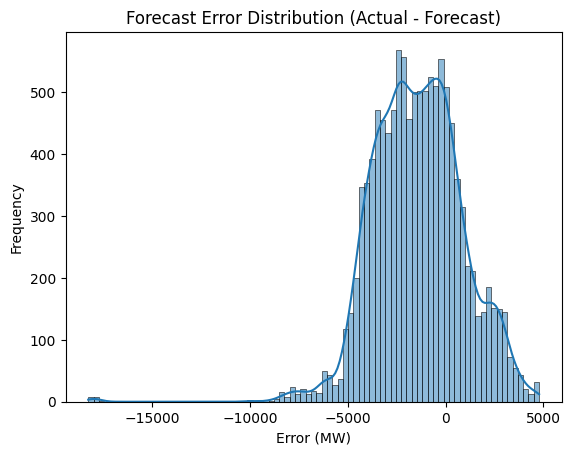

In [17]:
sns.histplot(errors, kde=True)
plt.xlabel("Error (MW)")
plt.ylabel("Frequency")
plt.title("Forecast Error Distribution (Actual - Forecast)")
plt.show()

This histogram shows the following:

- The model systematically **overpredicts** the wind power.
- Typically the model predicts **1000-2000 MW higher** than actual, showing the model uncertainty.
- The far left tail around **-10000 MW to -15000 MW** indicates rare but very large errors.

Additionally,

The distribution seems to follow bell-curve - which means a normal distribution, but biased to the negative values.

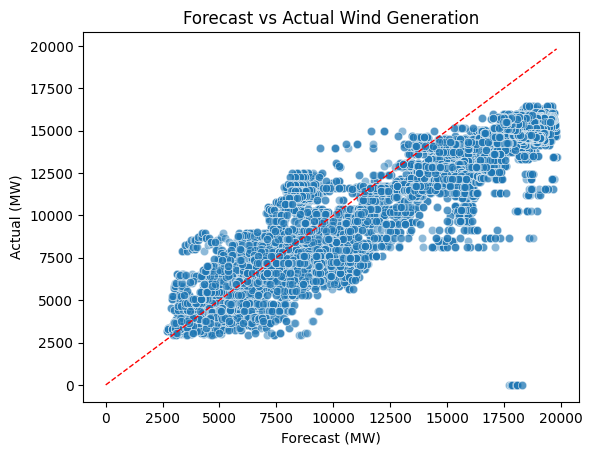

In [ ]:
sns.scatterplot(data=df, x="forecast", y="actual", alpha=0.5)

# Plot x=y reference line across the data range
min_val = min(df["forecast"].min(), df["actual"].min())
max_val = max(df["forecast"].max(), df["actual"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1)

plt.xlabel("Forecast (MW)")
plt.ylabel("Actual (MW)")
plt.title("Forecast vs Actual Wind Generation")
plt.show()

This line plot shows:

- The model systematically **overpredicts** the wind power. Already seen in the histogram plot.
- The model was able to capture the **trend in wind power**, although overpredicted.
- In the start, there are cases of underprediction but it is less frequent.
- Errors **start increasing at higher wind generation** shown via the spread on the upper right graph.

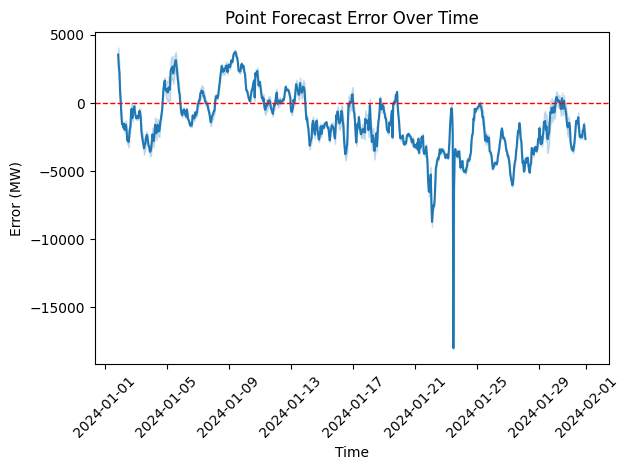

In [18]:
sns.lineplot(x=df["targetTime"], y=errors)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Error (MW)")
plt.title("Point Forecast Error Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This time series shows:

- The model tend to **overpredit during the mid-late January** 2024 time period.
- The model has **consistent error pattern**. From 1-10 Jan there are less error, 11-20 Jan there are negative errors and from 20 Jan onwards there are large negative errors. This shows that forecast errors occur in clusters of time due to persistent weather patterns.
- The model occastionally produced huge errors most probably due to sudden wind drop or storm.

## Forecast Error VS Forecast Horizon

In [ ]:
# Calculate forecast horizon in hours
df["horizon"] = (df["targetTime"] - df["publishTime"]).dt.total_seconds() / 3600

results = []
for horizon in range(0, 49):
    filtered = df[df["horizon"] >= horizon]
    errors = filtered["actual"] - filtered["forecast"]
    mae = errors.abs().mean()
    rmse = (errors ** 2).mean() ** 0.5
    results.append({
        "horizon": horizon,
        "mae":     mae,
        "rmse":    rmse,
        "count":   len(filtered),
    })

metrics_df = pd.DataFrame(results)

/tmp/ipykernel_1440/3923455160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["horizon"] = (df["targetTime"] - df["publishTime"]).dt.total_seconds() / 3600


In [ ]:
metrics_df.head()

,horizon,mae,rmse,count
0,0,2148.643787,2701.162402,11524
1,1,2149.661041,2702.088797,11494
2,2,2150.401867,2702.844953,11464
3,3,2152.347334,2704.734692,11404
4,4,2153.600229,2705.132666,11344


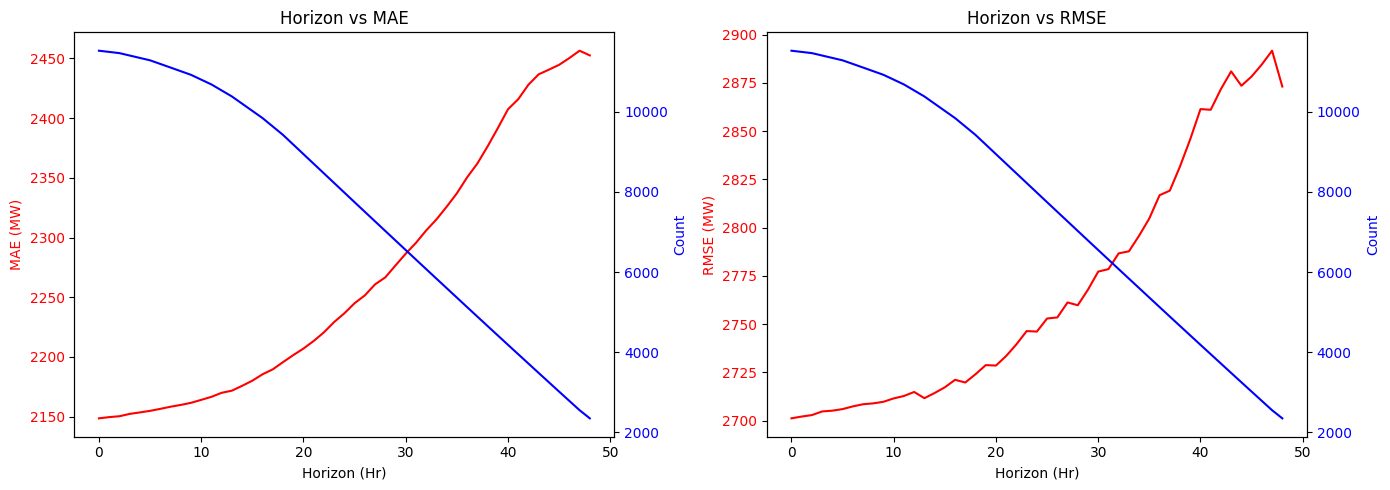

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE plot
ax1 = axes[0]
ax1.plot(metrics_df["horizon"], metrics_df["mae"], color="red", label="MAE")
ax1.set_xlabel("Horizon (Hr)")
ax1.set_ylabel("MAE (MW)", color="red")
ax1.tick_params(axis="y", labelcolor="red")
ax2 = ax1.twinx()
ax2.plot(metrics_df["horizon"], metrics_df["count"], color="blue", label="Count")
ax2.set_ylabel("Count", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")
ax1.set_title("Horizon vs MAE")

# RMSE plot
ax3 = axes[1]
ax3.plot(metrics_df["horizon"], metrics_df["rmse"], color="red", label="RMSE")
ax3.set_xlabel("Horizon (Hr)")
ax3.set_ylabel("RMSE (MW)", color="red")
ax3.tick_params(axis="y", labelcolor="red")
ax4 = ax3.twinx()
ax4.plot(metrics_df["horizon"], metrics_df["count"], color="blue", label="Count")
ax4.set_ylabel("Count", color="blue")
ax4.tick_params(axis="y", labelcolor="blue")
ax3.set_title("Horizon vs RMSE")

plt.tight_layout()
plt.show()

These two line plot shows:

- The model performs **best for short-term forecasts**, and accuracy gradually degrades as the forecast horizon increases.
- Forecast **reliability drops noticeably for horizons greater than ~24 hours**.
- The difference between RMSE and MAE suggests large forecast errors occasionally occur, because RMSE penalizes extreme errors more strongly.
- Long-horizon error estimates are based on fewer observations, which may make them slightly less stable.